In [32]:
import os
import sys
from pathlib import Path

current = Path.cwd()
project_root = None
for candidate in [current, *current.parents]:
    if (candidate / "nasarbadi_helper.py").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = current

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

import mne
import pywt
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import nasarbadi_helper


In [33]:
import os
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "nasarbadi_helper.py").exists():
    for candidate in project_root.parents:
        if (candidate / "nasarbadi_helper.py").exists():
            project_root = candidate
            break

os.chdir(project_root)
all_subjects = pd.read_csv(project_root / "datasets" / "metadata" / "nasarbadi_subject_index.csv")["ID"].tolist()


Pre-processing Steps:
1. IIR Butterworth Filter (Order 6, 0.5–60 Hz)
2. IIR Notch filter (50 Hz)
3. 4-second segments

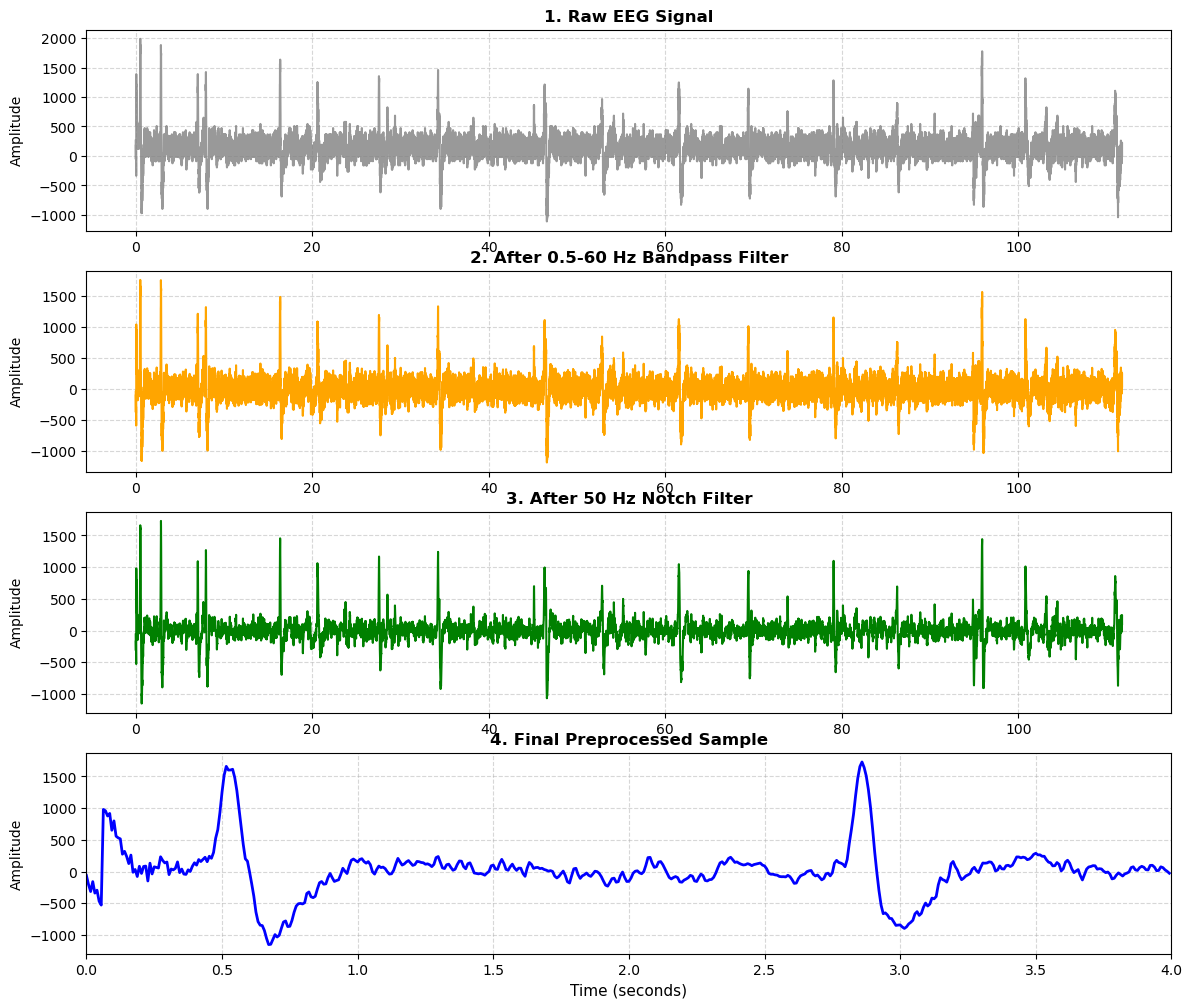

In [34]:
#IIR Butterworth Filter (Order 6, 0.5–60 Hz)
#Apply this filter to all the channels in all the subjects.

#Testing for the first subject for channel Fp1
subject_id = all_subjects[0]
subject_data, class_label = nasarbadi_helper.get_subject_info(subject_id)
fs = 128
data = subject_data["Fp1"]
t_full = np.arange(len(data)) / fs

sos_bandpass = signal.butter(6, [0.5,60], btype='bandpass', fs=128, output='sos')
filtered_bandpass = signal.sosfiltfilt(sos_bandpass, data)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

# Plot 1: Raw EEG Data
axes[0].plot(t_full, data, color='gray', alpha=0.8)
axes[0].set_title("1. Raw EEG Signal", fontsize=12, weight='bold')
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: After Bandpass
axes[1].plot(t_full, filtered_bandpass, color='orange')
axes[1].set_title("2. After 0.5-60 Hz Bandpass Filter", fontsize=12, weight='bold')
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, linestyle='--', alpha=0.5)


#IIR Notch filter (50 Hz)
b_notch, a_notch = signal.iirnotch(50.0, Q=30.0, fs=fs)
filtered_cleaned = signal.filtfilt(b_notch, a_notch, filtered_bandpass)

axes[2].plot(t_full, filtered_cleaned, color='green')
axes[2].set_title("3. After 50 Hz Notch Filter", fontsize=12, weight='bold')
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, linestyle='--', alpha=0.5)

#4-second segments
segment_duration = 4  
samples_per_segment = segment_duration * fs
t_segment = np.arange(samples_per_segment) / fs
num_segments = len(filtered_cleaned) // samples_per_segment
segmented_data = filtered_cleaned[:num_segments * samples_per_segment].reshape(num_segments, samples_per_segment)

axes[3].plot(t_segment, segmented_data[0], color='blue', linewidth=2)
axes[3].set_title("4. Final Preprocessed Sample", fontsize=12, weight='bold')
axes[3].set_xlabel("Time (seconds)", fontsize=11)
axes[3].set_ylabel("Amplitude")
axes[3].set_xlim(0, 4)
axes[3].grid(True, linestyle='--', alpha=0.5)
plt.show()


In [35]:
print(subject_data.columns)

Index(['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7',
       'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz'],
      dtype='object')


In [36]:
#Pre-processing Pipeline 

notebook_dir = Path.cwd() 
project_root = notebook_dir 
output_dir = project_root / "datasets" / "adhd-aid-data"

output_dir.mkdir(parents=True, exist_ok=True)

def iir_butterworth_filter(data, order=6, freq_range=[0.5, 60.0], fs=128):
    sos_bandpass = signal.butter(order, freq_range, btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos_bandpass, data)

def iir_notch_filter(data, notch_freq=50.0, Q=30.0, fs=128):
    b_notch, a_notch = signal.iirnotch(notch_freq, Q=Q, fs=fs)
    return signal.filtfilt(b_notch, a_notch, data)

def four_sec_segment(data, segment_duration=4, fs=128):
    samples_per_segment = segment_duration * fs
    num_segments = len(data) // samples_per_segment
    return data[:num_segments * samples_per_segment].reshape(num_segments, samples_per_segment)

fs = 128

for subject_id in all_subjects:
    # Load raw data for this subject
    subject_data, class_label = nasarbadi_helper.get_subject_info(subject_id)

    file_name = f"subject_{subject_id}.npy"
    file_path = output_dir / file_name

    if file_path.exists():
        print(f"Skipping subject {subject_id}: '{file_name}' already exists.")
        continue

    subject_processed_channels = []
    for channel in subject_data.columns:
        raw_data = subject_data[channel].values
        
        # Preprocessing cascade
        bandpassed = iir_butterworth_filter(raw_data, fs=fs)
        cleaned = iir_notch_filter(bandpassed, fs=fs)
        segmented = four_sec_segment(cleaned, fs=fs)
        
        subject_processed_channels.append(segmented)
    
    subject_array = np.array(subject_processed_channels)
    
    file_name = f"subject_{subject_id}.npy"
    file_path = output_dir / file_name
    

    np.save(file_path, subject_array)
    print(f"Saved: {file_name} | Array Shape: {subject_array.shape}")

Skipping subject v10p: 'subject_v10p.npy' already exists.
Skipping subject v12p: 'subject_v12p.npy' already exists.
Skipping subject v14p: 'subject_v14p.npy' already exists.
Skipping subject v15p: 'subject_v15p.npy' already exists.
Skipping subject v173: 'subject_v173.npy' already exists.
Skipping subject v18p: 'subject_v18p.npy' already exists.
Skipping subject v19p: 'subject_v19p.npy' already exists.
Skipping subject v1p: 'subject_v1p.npy' already exists.
Skipping subject v20p: 'subject_v20p.npy' already exists.
Skipping subject v21p: 'subject_v21p.npy' already exists.
Skipping subject v22p: 'subject_v22p.npy' already exists.
Skipping subject v24p: 'subject_v24p.npy' already exists.
Skipping subject v25p: 'subject_v25p.npy' already exists.
Skipping subject v27p: 'subject_v27p.npy' already exists.
Skipping subject v28p: 'subject_v28p.npy' already exists.
Skipping subject v29p: 'subject_v29p.npy' already exists.
Skipping subject v30p: 'subject_v30p.npy' already exists.
Skipping subject

In [37]:
file_path = project_root/ "datasets" / "adhd-aid-data" / "subject_v1p.npy"
new_data = np.load(file_path)
print(new_data.shape)



(19, 23, 512)


1. Channels for the specific subject -> 19
2. Segments -> 28 
3. Total Recording -> 512

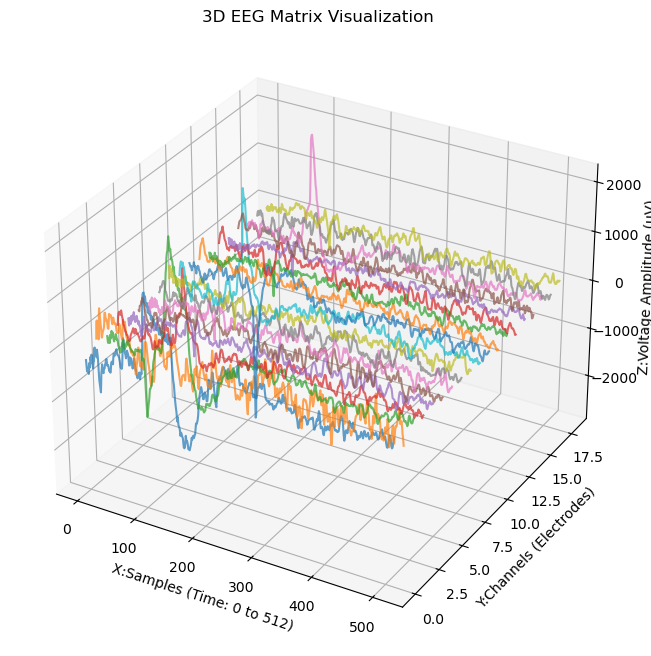

In [ ]:
data = np.load("datasets/adhd-aid-data/subject_v1p.npy") 
num_channels, num_segments, num_samples = data.shape


X, Y = np.meshgrid(np.arange(num_samples), np.arange(num_channels))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


for seg in range(min(1, num_segments)): 
    for ch in range(num_channels):
        ax.plot(
            xs=np.arange(num_samples),        # X-axis: 512 time samples
            ys=np.full(num_samples, ch),      # Y-axis: Channels (0-18)
            zs=data[ch, seg, :] + (seg * 500), # Z-axis: Amplitude (offset per segment)
            alpha=0.7
        )

ax.set_xlabel('X:Samples (Time: 0 to 512)')
ax.set_ylabel('Y:Channels (Electrodes)')
ax.set_zlabel('Z:Voltage Amplitude (µV)')
ax.set_title('3D EEG Matrix Visualization')
plt.show()

**Multi-Resolution Analysis and Feature Extraction**
1. DWT
2. EWT
3. VMD

In [31]:
#VMD

import numpy as np
from sktime.libs.vmdpy import VMD

# 1. Load your preprocessed 3D data: (Channels, Segments, Samples)
subject_data = np.load("datasets/adhd-aid-data/subject_v1p.npy")
num_channels, num_segments, num_samples = subject_data.shape

#VMD parameters from the paper (MATLAB 2022a)
K = 9        
alpha = 2000 
tau = 0      
DC = 0       
init = 1     
tol = 1e-7  

all_segments_features = []

print(subject_data)


[[[-2.44779760e+02 -4.72734889e+02 -3.97102095e+02 ... -1.31094551e+02
   -2.96999786e+01  5.33502940e+01]
  [ 7.57822060e+01  1.30962686e+02  1.17061843e+02 ...  1.37699730e+02
    1.00211670e+02  6.27920112e+01]
  [ 9.94060678e+00 -1.03375920e+02 -1.49444555e+02 ...  8.78460984e+00
   -6.31592817e+01  4.51855844e+01]
  ...
  [-2.65670983e+02 -3.35914825e+02 -2.49515418e+02 ...  1.95677774e+02
    2.24482278e+02  1.88031118e+02]
  [ 1.75461445e+02  1.93409259e+02  1.92814762e+02 ... -6.48791428e+01
   -3.62002362e+01 -1.17350036e+01]
  [-5.68678995e+01 -8.00326969e+01 -7.92182877e+01 ...  1.67945611e+02
    6.48488782e+01 -7.78873808e+01]]

 [[ 1.64877482e+01  3.13828081e+02  3.88689651e+02 ... -5.04143946e+01
   -1.40498681e+02 -2.74124734e+02]
  [-2.14995994e+02 -1.23178754e+02 -1.27158369e+02 ... -1.26253700e+02
   -2.53697949e+02 -4.24881964e+02]
  [-3.37319269e+02 -3.46465449e+02 -6.41625001e+02 ...  4.92309628e+02
    4.41811430e+02  3.88952139e+02]
  ...
  [ 5.48801760e+01  1.2

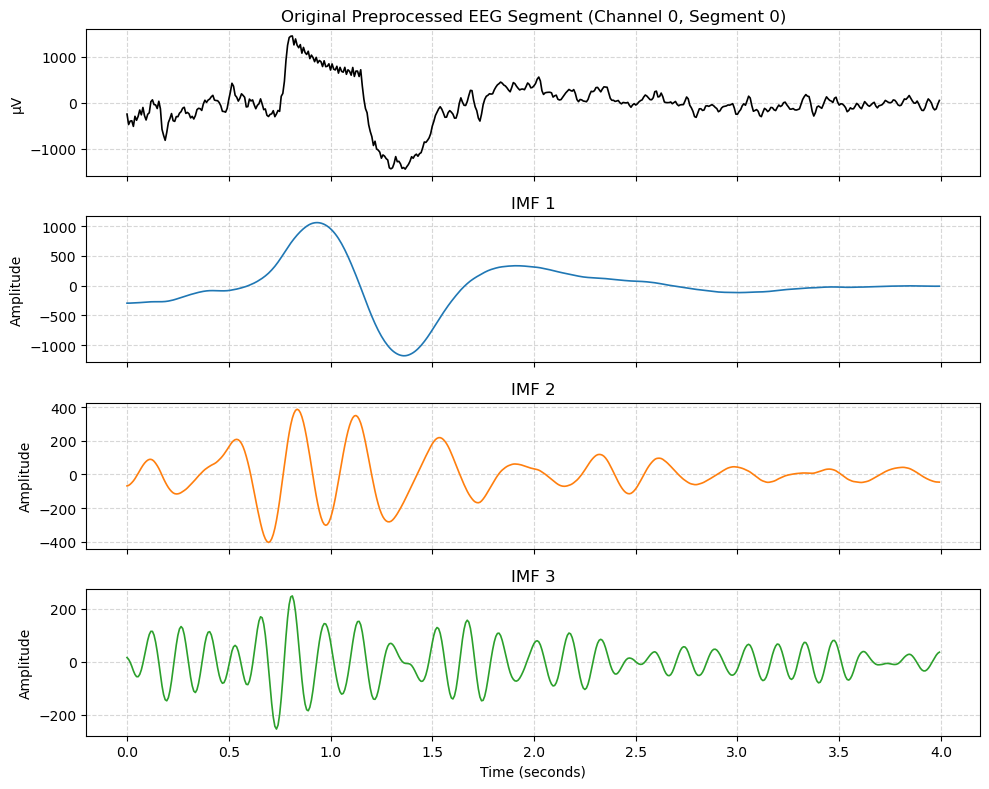

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.libs.vmdpy import VMD

# --- 1. Load Data ---
file_path = output_dir / "subject_v1p.npy"  # Adjust file name as needed
subject_data = np.load(file_path)

# Extract 1 channel, 1 segment (e.g., Channel 0, Segment 0 -> 512 samples)
fs = 128
raw_segment = subject_data[0, 0, :]  
time_axis = np.arange(len(raw_segment)) / fs  # 0 to 4 seconds

# --- 2. Run VMD ---
alpha = 2000
tau = 0
K = 9  # Extracts 9 modes total
DC = 0
init = 1
tol = 1e-7

# u shape: (9, 512)
u, u_hat, omega = VMD(raw_segment, alpha, tau, K, DC, init, tol)

# --- 3. Plot Original + First 3 IMFs ---
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Original Signal
axes[0].plot(time_axis, raw_segment, color='black', linewidth=1.2)
axes[0].set_title("Original Preprocessed EEG Segment (Channel 0, Segment 0)")
axes[0].set_ylabel("µV")
axes[0].grid(True, linestyle='--', alpha=0.5)

# IMF 1, IMF 2, IMF 3
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i in range(3):
    axes[i + 1].plot(time_axis, u[i, :], color=colors[i], linewidth=1.2)
    axes[i + 1].set_title(f"IMF {i + 1}")
    axes[i + 1].set_ylabel("Amplitude")
    axes[i + 1].grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()